In [1]:
import numpy as np
import pandas as pd

df = pd.read_parquet('../data/processed/icm_features.parquet')
print(df.shape)
print(df.columns.tolist())

(288, 11)
['fecha', 'valor', 'valor_icm_clean', 'mes', 'anyo', 'es_navidad', 'es_rebajas', 'lag_1', 'lag_12', 'rolling_mean_3', 'valor_ipc']


## Baseline

In [2]:
from src.functions import walk_forward_validation, naive_seasonal

serie = df.set_index('fecha')['valor_icm_clean']
serie.index.freq = serie.index.inferred_freq

resultado_naive = walk_forward_validation(
    data=serie,
    modelo_func=naive_seasonal,
    min_train=96,
    horizonte=3
)

print(f"Baseline Naive Seasonal:")
print(f"MAPE medio: {resultado_naive['mape_medio']:.4f}")
print(f"MAPE std: {resultado_naive['mape_std']:.4f}")
print(f"Ventanas evaluadas: {resultado_naive['n_ventanas']}")

Baseline Naive Seasonal:
MAPE medio: 0.0373
MAPE std: 0.0268
Ventanas evaluadas: 64


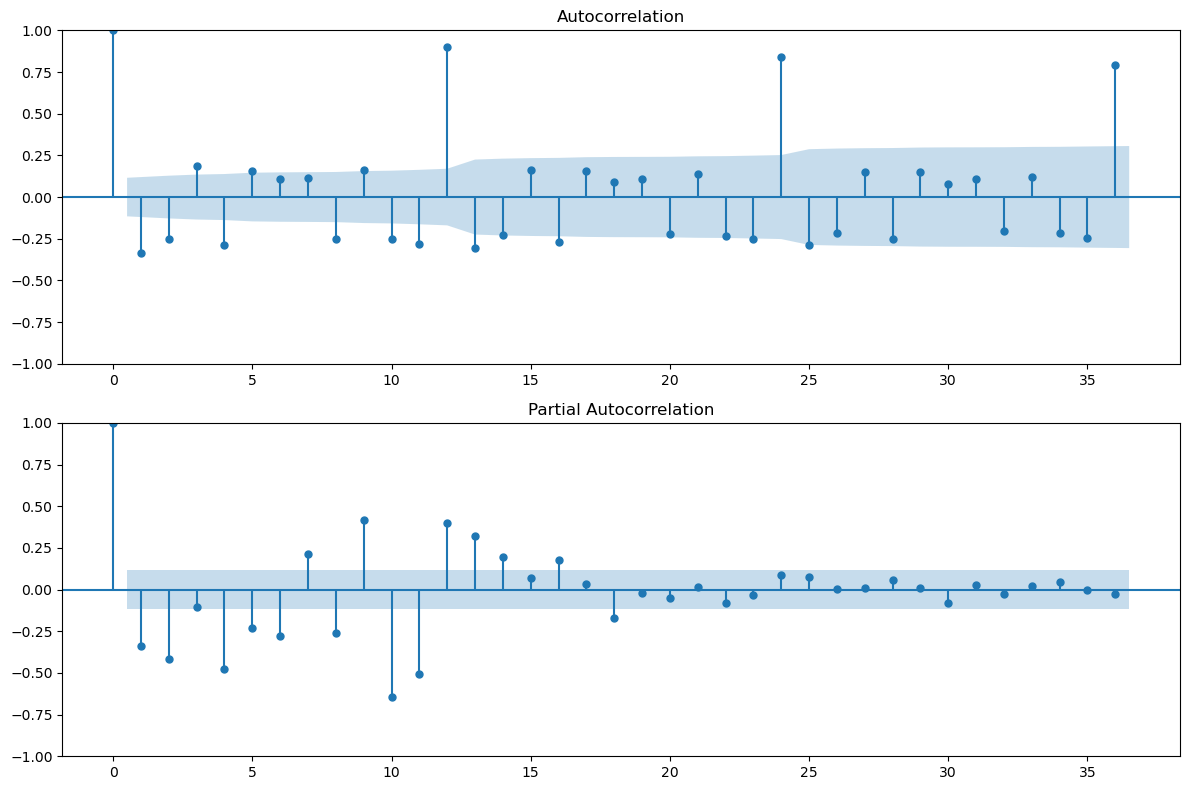

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['valor_icm_clean'].diff().dropna(), lags=36, ax=axes[0])
plot_pacf(df['valor_icm_clean'].diff().dropna(), lags=36, ax=axes[1])

plt.tight_layout()
plt.savefig('../reports/figures/06_acf_pacf.png', dpi=150)
plt.show()

In [5]:
from pmdarima import auto_arima

modelo_auto = auto_arima(
    df['valor_icm_clean'],
    seasonal=True,
    m=12,
    d=1,
    D=1,
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(modelo_auto.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  288
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -651.944
Date:                            Mon, 22 Jun 2026   AIC                           1313.889
Time:                                    22:10:03   BIC                           1331.973
Sample:                                         0   HQIC                          1321.146
                                            - 288                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9095      0.113     -8.016      0.000      -1.132      -0.687
ar.L2         -0.5134      0.054   

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarima_model(train, horizonte):
    modelo = SARIMAX(
        train,
        order=(2, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    resultado = modelo.fit(disp=False)
    predicciones = resultado.forecast(steps=horizonte)
    return predicciones.values

resultado_sarima = walk_forward_validation(
    data=serie,
    modelo_func=sarima_model,
    min_train=96,
    horizonte=3
)

print(f"SARIMA:")
print(f"MAPE medio: {resultado_sarima['mape_medio']:.4f}")
print(f"MAPE std: {resultado_sarima['mape_std']:.4f}")

SARIMA:
MAPE medio: 0.0205
MAPE std: 0.0165


In [15]:
# Prueba con prophet
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING) # silenciar los outputs de prophet
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

def prophet_model(train, horizonte):
    df_prophet = pd.DataFrame({
        'ds': train.index,
        'y': train.values
    })
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative'
    )
    
    model.fit(df_prophet)
    
    futuro = model.make_future_dataframe(periods=horizonte, freq='MS')
    forecast = model.predict(futuro)
    
    # Retornamos las ultimas horizonte filas que son la prediccion futura
    return forecast['yhat'].tail(horizonte).values

resultado_prophet = walk_forward_validation(
    data=serie,
    modelo_func=prophet_model,
    min_train=96,
    horizonte=3
)

print(f"Prophet:")
print(f"MAPE medio: {resultado_prophet['mape_medio']:.4f}")
print(f"MAPE std: {resultado_prophet['mape_std']:.4f}")

Prophet:
MAPE medio: 0.0312
MAPE std: 0.0192


In [8]:
# Prueba con LigthGBM
import lightgbm as lgbm

features = ['mes', 'anyo', 'es_navidad', 'es_rebajas', 'lag_1', 'lag_12', 'rolling_mean_3', 'valor_ipc']
target = 'valor_icm_clean'

def lightgbm_model(X_train, y_train, X_test):
    modelo = lgbm.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    
    modelo.fit(X_train, y_train)
    return modelo.predict(X_test)

resultado_lgbm = walk_forward_validation(
    data=df,
    modelo_func=lightgbm_model,
    min_train=96,
    horizonte=3,
    features=features,
    target=target
)

print(f"LightGBM:")
print(f"MAPE medio: {resultado_lgbm['mape_medio']:.4f}")
print(f"MAPE std: {resultado_lgbm['mape_std']:.4f}")

LightGBM:
MAPE medio: 0.0328
MAPE std: 0.0260


# Tabla de modelos

| Modelo | MAPE medio |
| :--- | :---: |
| SARIMA | 2.05% |
| Prophet | 3.12% |
| LightGBM (con lags + IPC) | 3.28% |
| LightGBM (con lags) | 3.31% |
| Naive Seasonal | 3.73% |
| LightGBM (sin lags) | 4.96% |

1. SARIMA domina con MAPE de 2.05% vs 3.12% de Prophet y 3.28% de LightGBM.
2. Las features importan más que el modelo — LightGBM sin lags pierde contra el baseline (4.96% vs 3.73%)
3. El IPC como regresor externo aporta valor marginal cuando ya tienes lags (0.03% de valor añadido)

## Predicción con SARIMA

In [6]:

fecha_corte = '2024-12-01'
train_sarima = serie[serie.index <= fecha_corte]
test_sarima = serie[serie.index > fecha_corte].iloc[:3]

modelo_final = SARIMAX(
    train_sarima,
    order=(2, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_final = modelo_final.fit(disp=False)
predicciones_final = resultado_final.forecast(steps=3)
intervalos = resultado_final.get_forecast(steps=3).conf_int()

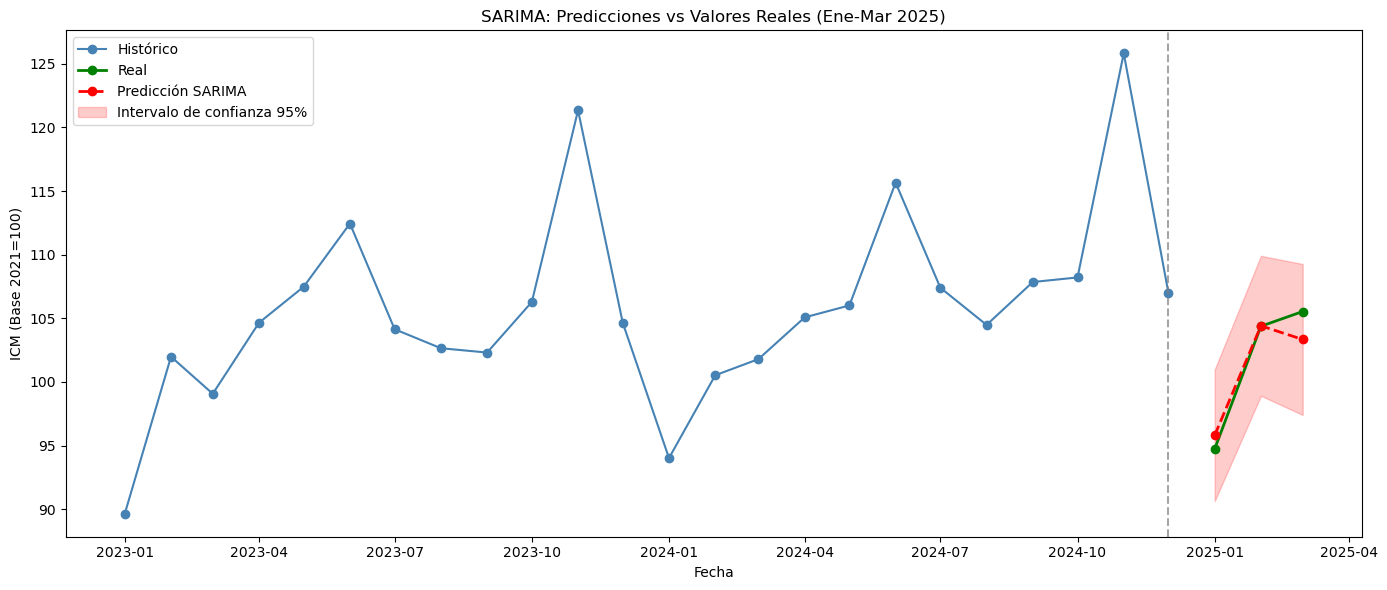

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

# Serie histórica - últimos 24 meses
ax.plot(train_sarima.index[-24:], train_sarima.iloc[-24:], 
        label='Histórico', color='steelblue', marker='o')

# Valores reales del test
ax.plot(test_sarima.index, test_sarima.values, 
        label='Real', color='green', marker='o', linewidth=2)

# Predicciones
ax.plot(predicciones_final.index, predicciones_final.values, 
        label='Predicción SARIMA', color='red', marker='o', linewidth=2, linestyle='--')

# Intervalos de confianza
ax.fill_between(intervalos.index, 
                intervalos.iloc[:, 0], 
                intervalos.iloc[:, 1], 
                alpha=0.2, color='red', label='Intervalo de confianza 95%')

ax.axvline(x=pd.Timestamp(fecha_corte), color='gray', linestyle='--', alpha=0.7)
ax.set_title('SARIMA: Predicciones vs Valores Reales (Ene-Mar 2025)')
ax.set_xlabel('Fecha')
ax.set_ylabel('ICM (Base 2021=100)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_predicciones_vs_real.png', dpi=150)
plt.show()